# Tên Đề Tài: Nhận Diện Hành Vi Bạo Lực Từ Camera Giám Sát Bằng Mạng Nơ-ron Không Gian - Thời Gian Kết Hợp Cơ Chế Chú Ý

## 1. Tóm tắt (Abstract)
Nghiên cứu này đề xuất một kiến trúc Deep Learning tối ưu cho bài toán nhận diện bạo lực trên CCTV. Hệ thống kết hợp khả năng trích xuất đặc trưng không gian của **MobileNetV2** và mạng bộ nhớ dài ngắn hai chiều **BiLSTM** để bắt các chuyển động phức tạp. Điểm đột phá của nghiên cứu là việc tích hợp **Temporal Attention Mechanism**, giúp mô hình loại bỏ nhiễu từ các khung hình tĩnh và tập trung vào các khoảnh khắc xảy ra hành vi bất thường. Hàm mất mát **Focal Loss** được áp dụng để giải quyết vấn đề mất cân bằng trong các mẫu khó nhận diện.

## 2. Chuẩn bị môi trường (Environment Setup)

In [1]:
!apt-get update -y && apt-get install -y ffmpeg libsm6 libxext6

# TẮT SPAM LOG TẠI ĐÂY (Phải đặt trước khi import cv2 và tf)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['OPENCV_FFMPEG_LOGLEVEL'] = '0'
os.environ['OPENCV_LOG_LEVEL'] = 'SILENT'

import re, cv2, random, time, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import *
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from concurrent.futures import ThreadPoolExecutor
import tensorflow.keras.backend as K

# ====================== GLOBAL REPRODUCIBILITY & GPU STABILITY ======================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"✅ Global seed = {SEED} (reproducibility)")

# Giới hạn GPU memory growth để tránh OOM trên Kaggle
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled (prevent OOM)")
    except RuntimeError as e:
        print(f"⚠️ {e}")

# Tắt nốt warning rác của Keras
tf.get_logger().setLevel('ERROR')

# Tối ưu hóa GPU trên Kaggle
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("✅ Hệ thống sẵn sàng với GPU:", tf.config.list_physical_devices('GPU'))

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://packages.cloud.google.com/apt gcsfuse-focal InRelease [1227 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://packages.cloud.google.com/apt cloud-sdk InRelease [1620 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2473 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://packages.cloud.google.com/apt google-fast-socket InRelease [1071 B]
Get:9 https://packages.cloud.google.com/apt gcsfuse-focal/main amd64 Packages [62.6 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1307 kB]
Get:13 http://securi

In [2]:
# =====================================================================
# 📁 TẠO THƯ MỤC OUTPUT ĐỂ LƯU MÔ HÌNH & BIỂU ĐỒ
# =====================================================================
import os, zipfile
from datetime import datetime

OUTPUT_DIR = '/kaggle/working/output_results'
os.makedirs(f'{OUTPUT_DIR}/models',   exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/charts',   exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/reports',  exist_ok=True)

# Cập nhật tên file model để lưu vào thư mục output
MODEL_NAME    = f'{OUTPUT_DIR}/models/CCTV_Violence_Final.keras'
MODEL_NAME_FT = f'{OUTPUT_DIR}/models/CCTV_Violence_Finetuned.keras'

print(f"✅ Đã tạo thư mục output: {OUTPUT_DIR}")
print(f"   ├── models/   → Lưu file .keras")
print(f"   ├── charts/   → Lưu biểu đồ .png")
print(f"   └── reports/  → Lưu báo cáo .txt")


✅ Đã tạo thư mục output: /kaggle/working/output_results
   ├── models/   → Lưu file .keras
   ├── charts/   → Lưu biểu đồ .png
   └── reports/  → Lưu báo cáo .txt


## 3. Phương pháp luận: Quản lý Dữ liệu Đa Nguồn (Cross-Dataset Management)
Để đảm bảo mô hình có khả năng khái quát hóa cao và không bị học vẹt bối cảnh (Scene Leakage), dữ liệu được gom cụm theo từng đoạn video gốc và phân chia theo tỷ lệ Train/Val/Test khắt khe thông qua `GroupShuffleSplit`.

In [3]:
IMG_SIZE = 128
FRAME_COUNT = 15
BATCH_SIZE = 32
EPOCHS = 15
CLASSES = ['Normal', 'Violence']

SOURCES = [
    Path('/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split'),
    Path('/kaggle/input/rwf2000/RWF-2000'),
    Path('/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset')
]

def canonical_scene_key(path: Path) -> str:
    stem = path.stem.lower()
    stem = re.sub(r'(_clip\d+|_part\d+|_seg\d+|-clip\d+|-part\d+)$', '', stem)
    return f"{path.parent.name.lower()}::{stem}"

def load_data():
    records = []
    for base in SOURCES:
        if not base.exists(): continue
        for path in base.rglob('*'):
            if path.suffix.lower() not in ['.mp4', '.avi']: continue
            folder = path.parent.name.lower()
            if folder in ['normal', 'nonfight', 'nonviolence']: label = 0
            elif folder in ['violence', 'weaponized', 'fight']: label = 1
            else: continue
            group_id = f"{base.name}::{canonical_scene_key(path)}"
            records.append((str(path), label, group_id, base.name))
    return records

records = load_data()
paths = np.array([r[0] for r in records])
labels = np.array([r[1] for r in records])
groups = np.array([r[2] for r in records])

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_val_idx, test_idx = next(gss_test.split(paths, labels, groups))
p_tv, y_tv, g_tv = paths[train_val_idx], labels[train_val_idx], groups[train_val_idx]
X_test_p, y_test, g_test = paths[test_idx], labels[test_idx], groups[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1111, random_state=42)
train_idx, val_idx = next(gss_val.split(p_tv, y_tv, g_tv))
X_train_p, y_train, g_train = p_tv[train_idx], y_tv[train_idx], g_tv[train_idx]
X_val_p, y_val, g_val = p_tv[val_idx], y_tv[val_idx], g_tv[val_idx]

print(f"📊 Số lượng Video: Train={len(X_train_p)} | Val={len(X_val_p)} | Test={len(X_test_p)}")
print("🔒 Kiểm tra rò rỉ dữ liệu (Scene Leakage - Phải bằng 0):",
      len(set(g_train).intersection(set(g_test))))
print("🔒 Kiểm tra rò rỉ val ↔ test (Phải bằng 0):",
      len(set(g_val).intersection(set(g_test))))

def print_class_dist(y, name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    print(f"📊 Phân phối class {name}: Normal={counts[0]} ({counts[0]/total*100:.1f}%) | "
          f"Violence={counts[1] if len(counts)>1 else 0} ({(counts[1]/total*100 if len(counts)>1 else 0):.1f}%) | Total={total}")

print_class_dist(y_train, "Train")
print_class_dist(y_val, "Val")
print_class_dist(y_test, "Test")

📊 Số lượng Video: Train=5720 | Val=715 | Test=716
🔒 Kiểm tra rò rỉ dữ liệu (Scene Leakage - Phải bằng 0): 0
🔒 Kiểm tra rò rỉ val ↔ test (Phải bằng 0): 0
📊 Phân phối class Train: Normal=2418 (42.3%) | Violence=3302 (57.7%) | Total=5720
📊 Phân phối class Val: Normal=301 (42.1%) | Violence=414 (57.9%) | Total=715
📊 Phân phối class Test: Normal=322 (45.0%) | Violence=394 (55.0%) | Total=716


## 4. Trích xuất đặc trưng và Tăng cường dữ liệu (Data Generator & Augmentation)
Video được trích xuất thành 15 frames, đưa về không gian màu chuẩn `[-1.0, 1.0]` của ImageNet. Kỹ thuật Random Crop và biến đổi nhiễu được áp dụng để tăng độ bền bỉ của mô hình.

In [4]:
def extract(path):
    f = []
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise IOError(f"⚠️ Không mở được video (file hỏng hoặc path sai): {path}")
    t = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    s = max(t // FRAME_COUNT, 1)
    for i in range(FRAME_COUNT):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * s)
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
        f.append(preprocess_input(frame.astype(np.float32)))
    cap.release()
    while len(f) < FRAME_COUNT:
        f.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) - 1.0)
    return np.array(f, dtype=np.float32)

def augment_video(frames):
    x = frames.copy()
    if random.random() < 0.5: x = x[:, :, ::-1, :]
    if random.random() < 0.3:
        crop_size = int(IMG_SIZE * 0.85)
        x_offset = random.randint(0, IMG_SIZE - crop_size)
        y_offset = random.randint(0, IMG_SIZE - crop_size)
        cropped = x[:, y_offset:y_offset+crop_size, x_offset:x_offset+crop_size, :]
        x = np.array([cv2.resize(img, (IMG_SIZE, IMG_SIZE)) for img in cropped])
    return x

class VideoGenerator(tf.keras.utils.Sequence):
    def __init__(self, p, l, augment=False):
        self.p, self.l, self.augment = list(p), list(l), augment
        self.ex = ThreadPoolExecutor(max_workers=8)

    def __len__(self):
        return int(np.ceil(len(self.p) / BATCH_SIZE))

    def __getitem__(self, i):
        bx = self.p[i * BATCH_SIZE:(i + 1) * BATCH_SIZE]
        by = self.l[i * BATCH_SIZE:(i + 1) * BATCH_SIZE]
        videos = np.array(list(self.ex.map(extract, bx)), dtype=np.float32)
        if self.augment:
            videos = np.array([augment_video(v) for v in videos], dtype=np.float32)
        return videos, tf.keras.utils.to_categorical(by, 2)

    def on_epoch_end(self):
        combined = list(zip(self.p, self.l))
        random.shuffle(combined)
        self.p, self.l = map(list, zip(*combined))

    def __del__(self):
        self.ex.shutdown(wait=False)

train_gen = VideoGenerator(X_train_p, y_train, augment=True)
val_gen   = VideoGenerator(X_val_p,   y_val,   augment=False)
test_gen  = VideoGenerator(X_test_p,  y_test,  augment=False)

## 5. Kiến trúc mô hình: CNN - BiLSTM - Attention
Sử dụng kỹ thuật Transfer Learning với MobileNetV2 để đóng vai trò Feature Extractor. Lớp Attention giúp phân bổ trọng số cho từng khung hình theo mức độ quan trọng.

In [5]:
@tf.keras.utils.register_keras_serializable()
class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_bias', shape=(1,),
                                  initializer='zeros', trainable=True)
        super(TemporalAttention, self).build(input_shape)

    def call(self, x):
        e = K.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        alpha = K.softmax(K.squeeze(e, axis=-1))
        context = x * K.expand_dims(alpha, axis=-1)
        return K.sum(context, axis=1), alpha

    def get_config(self):
        return super().get_config()

K.clear_session()
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

video_input = Input(shape=(FRAME_COUNT, IMG_SIZE, IMG_SIZE, 3))
x = Lambda(lambda z: tf.reshape(z, [-1, IMG_SIZE, IMG_SIZE, 3]))(video_input)
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Lambda(lambda z: tf.reshape(z, [-1, FRAME_COUNT, base_model.output_shape[-1]]))(x)

x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3))(x)
context_vector, attention_weights = TemporalAttention(name='attention_layer')(x)

x = Dense(64, activation='relu')(context_vector)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax', dtype='float32')(x)

model = Model(inputs=video_input, outputs=output)
attention_model = Model(inputs=video_input, outputs=[output, attention_weights])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
              metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 15, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 15, 128)        │       688,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ [(None, 128), (None,   │           129 │
│ (TemporalAttention)             │ 15)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,955,139 (11.27 MB)

 Trainable params: 697,155 (2.66 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Huấn luyện (Training)
### Giai đoạn 1: Huấn luyện với base model đóng băng

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_NAME, save_best_only=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 1595s 9s/step - accuracy: 0.5387 - loss: 0.0559 - val_accuracy: 0.6895 - val_loss: 0.0362 - learning_rate: 1.0000e-04
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 1511s 8s/step - accuracy: 0.6595 - loss: 0.0393 - val_accuracy: 0.7608 - val_loss: 0.0310 - learning_rate: 1.0000e-04
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 1505s 8s/step - accuracy: 0.7171 - loss: 0.0350 - val_accuracy: 0.7818 - val_loss: 0.0287 - learning_rate: 1.0000e-04
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 1496s 8s/step - accuracy: 0.7438 - loss: 0.0326 - val_accuracy: 0.8182 - val_loss: 0.0260 - learning_rate: 1.0000e-04
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 1512s 8s/step - accuracy: 0.7758 - loss: 0.0302 - val_accuracy: 0.8406 - val_loss: 0.0242 - learning_rate: 1.0000e-04
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 1530s 8s/step - accuracy: 0.7940 - loss: 0.0287 - val_accuracy: 0.8573 - val_loss: 0.0226 - learning_rate: 1.0000e-04
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 1525s 8s/step - accurac

### Giai đoạn 2: Fine-tuning — Unfreeze 30 layer cuối MobileNetV2

In [7]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
              metrics=['accuracy'])

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_NAME_FT, save_best_only=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_ft,
    verbose=1
)
print("✅ Fine-tuning hoàn thành!")

# ==================== BỔ SUNG: LƯU ATTENTION MODEL ====================
ATTENTION_MODEL_PATH = f'{OUTPUT_DIR}/models/CCTV_Violence_Attention.keras'
attention_model.save(ATTENTION_MODEL_PATH)
print(f"✅ Đã lưu attention_model cho XAI: {ATTENTION_MODEL_PATH}")

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1595s 8s/step - accuracy: 0.7517 - loss: 0.0437 - val_accuracy: 0.8629 - val_loss: 0.0224 - learning_rate: 1.0000e-05
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1530s 8s/step - accuracy: 0.8283 - loss: 0.0254 - val_accuracy: 0.8727 - val_loss: 0.0199 - learning_rate: 1.0000e-05
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1437s 8s/step - accuracy: 0.8656 - loss: 0.0208 - val_accuracy: 0.8755 - val_loss: 0.0198 - learning_rate: 1.0000e-05
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1433s 8s/step - accuracy: 0.8690 - loss: 0.0200 - val_accuracy: 0.8937 - val_loss: 0.0187 - learning_rate: 1.0000e-05
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1433s 8s/step - accuracy: 0.8774 - loss: 0.0191 - val_accuracy: 0.9007 - val_loss: 0.0178 - learning_rate: 1.0000e-05
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1436s 8s/step - accuracy: 0.8924 - loss: 0.0171 - val_accuracy: 0.8965 - val_loss: 0.0174 - learning_rate: 1.0000e-05
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1431s 8s/ste

## 7. Đánh giá và Trực quan hóa Kết quả (Results & Evaluation)

✅ Đã lưu: /kaggle/working/output_results/charts/01_learning_curves.png


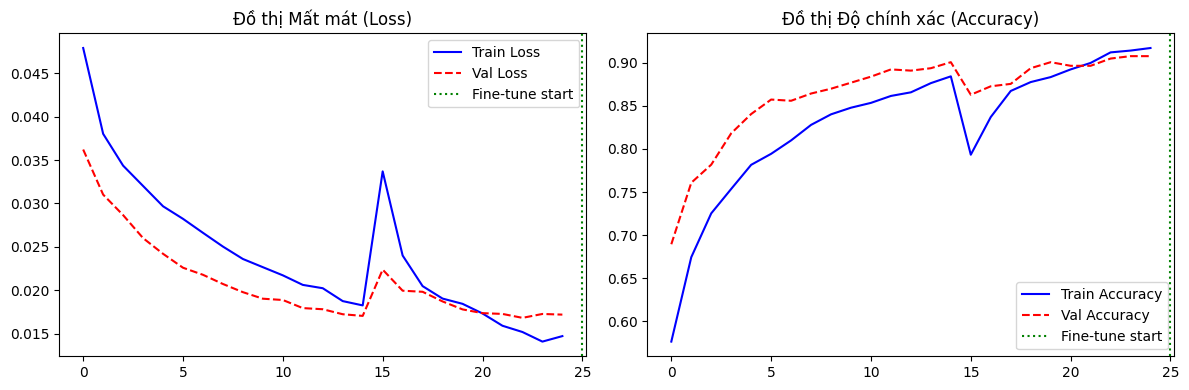

In [8]:
# =====================================================================
# 💾 LƯU BIỂU ĐỒ LEARNING CURVE
# =====================================================================
def plot_and_save_history(h1, h2=None, save_path=None):
    loss     = h1.history['loss']
    val_loss = h1.history['val_loss']
    acc      = h1.history['accuracy']
    val_acc  = h1.history['val_accuracy']
    if h2:
        loss     += h2.history['loss']
        val_loss += h2.history['val_loss']
        acc      += h2.history['accuracy']
        val_acc  += h2.history['val_accuracy']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(loss,     label='Train Loss',     color='blue')
    axes[0].plot(val_loss, label='Val Loss',       color='red', linestyle='--')
    if h2:
        axes[0].axvline(len(h1.history['loss']), color='green', linestyle=':', label='Fine-tune start')
    axes[0].set_title('Đồ thị Mất mát (Loss)'); axes[0].legend()

    axes[1].plot(acc,     label='Train Accuracy', color='blue')
    axes[1].plot(val_acc, label='Val Accuracy',   color='red', linestyle='--')
    if h2:
        axes[1].axvline(len(h1.history['accuracy']), color='green', linestyle=':', label='Fine-tune start')
    axes[1].set_title('Đồ thị Độ chính xác (Accuracy)'); axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Đã lưu: {save_path}")
    plt.show()

plot_and_save_history(history, history_ft,
    save_path=f'{OUTPUT_DIR}/charts/01_learning_curves.png')


23/23 ━━━━━━━━━━━━━━━━━━━━ 161s 7s/step

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):
              precision    recall  f1-score   support

      Normal     0.4437    0.4037    0.4228       322
    Violence     0.5461    0.5863    0.5655       394

    accuracy                         0.5042       716
   macro avg     0.4949    0.4950    0.4941       716
weighted avg     0.5000    0.5042    0.5013       716

✅ Đã lưu: /kaggle/working/output_results/reports/classification_report.txt
✅ Đã lưu: /kaggle/working/output_results/charts/02_evaluation_charts.png


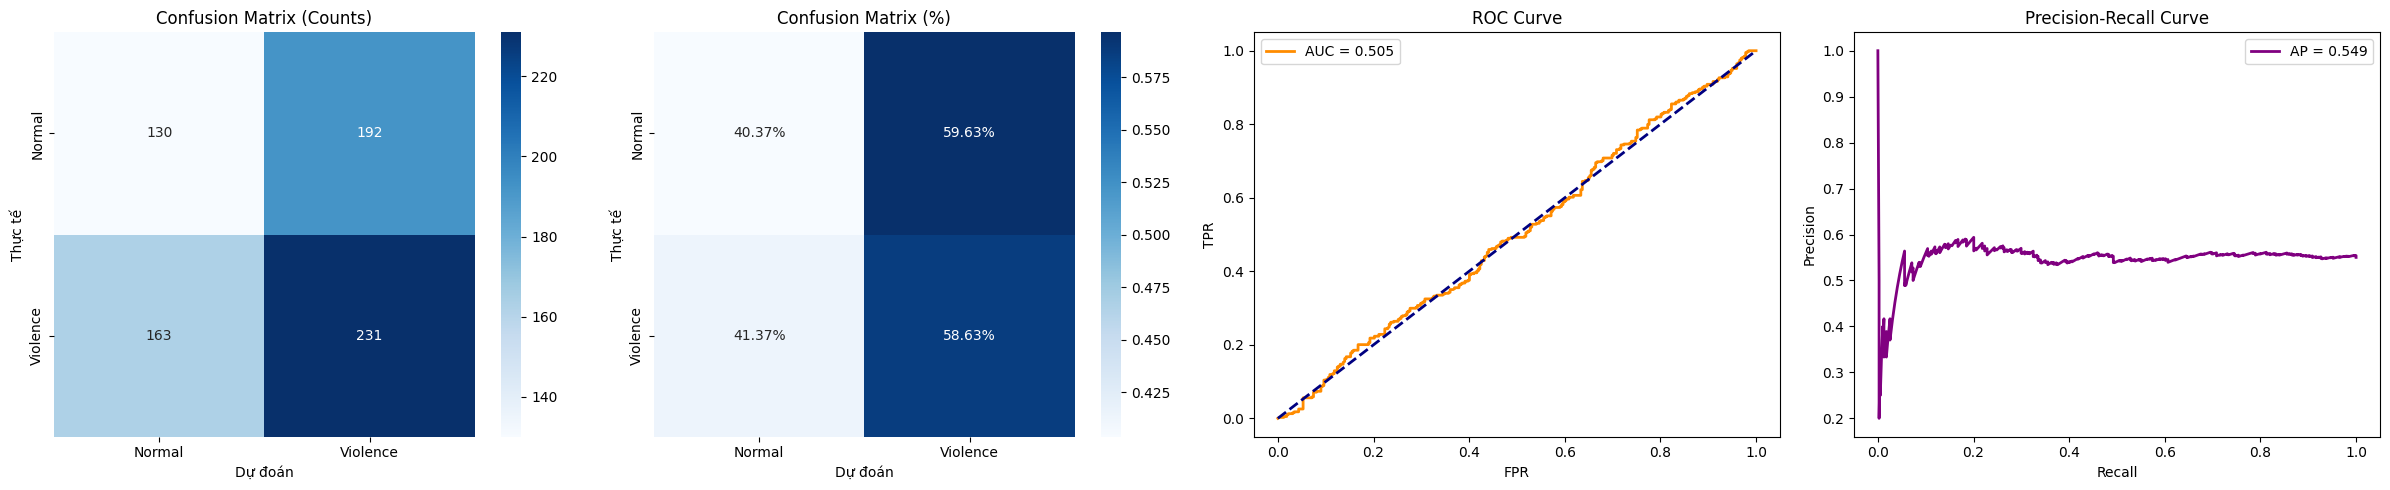

✅ Đã lưu model summary: /kaggle/working/output_results/reports/model_summary.txt
✅ Đã lưu config: /kaggle/working/output_results/reports/config.json


In [9]:
# =====================================================================
# 💾 LƯU BIỂU ĐỒ ĐÁNH GIÁ (Confusion Matrix + ROC + PR Curve)
# =====================================================================
from datetime import datetime
import json

y_pred_prob  = model.predict(test_gen)
y_pred_class = np.argmax(y_pred_prob, axis=1)
y_true_all   = np.concatenate([np.argmax(test_gen[i][1], axis=1) for i in range(len(test_gen))])

report_str = classification_report(y_true_all, y_pred_class, target_names=CLASSES, digits=4)
print("\nBÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):")
print(report_str)
report_path = f'{OUTPUT_DIR}/reports/classification_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(f"=== Violence Detection — Classification Report ===\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write(report_str)
print(f"✅ Đã lưu: {report_path}")

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# CM Count
cm = confusion_matrix(y_true_all, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

# CM %
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_ylabel('Thực tế'); axes[1].set_xlabel('Dự đoán')

# ROC
fpr, tpr, _ = roc_curve(y_true_all, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_title('ROC Curve'); axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR'); axes[2].legend()

# PR
precision, recall, _ = precision_recall_curve(y_true_all, y_pred_prob[:, 1])
ap = average_precision_score(y_true_all, y_pred_prob[:, 1])
axes[3].plot(recall, precision, color='purple', lw=2, label=f'AP = {ap:.3f}')
axes[3].set_title('Precision-Recall Curve'); axes[3].set_xlabel('Recall'); axes[3].set_ylabel('Precision'); axes[3].legend()

plt.tight_layout()
chart_path = f'{OUTPUT_DIR}/charts/02_evaluation_charts.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f"✅ Đã lưu: {chart_path}")
plt.show()

# Lưu summary + config
summary_path = f'{OUTPUT_DIR}/reports/model_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("=== Model Architecture Summary ===\n\n")
    model.summary(print_fn=lambda x: f.write(x + '\n'))
    f.write("\n\n=== Attention Model (XAI) Summary ===\n\n")
    attention_model.summary(print_fn=lambda x: f.write(x + '\n'))
print(f"✅ Đã lưu model summary: {summary_path}")

config = {
    "IMG_SIZE": IMG_SIZE, "FRAME_COUNT": FRAME_COUNT, "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS_PHASE1": EPOCHS, "EPOCHS_FINE_TUNE": 10, "SEED": 42,
    "CLASSES": CLASSES, "SOURCES": [str(s) for s in SOURCES],
    "GENERATED_AT": datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}
config_path = f'{OUTPUT_DIR}/reports/config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=4, ensure_ascii=False)
print(f"✅ Đã lưu config: {config_path}")

## 8. Trực quan hóa AI giải thích được (Explainable AI - XAI)


🔍 XAI Visualization cho video index #0 (1/4)
Thực tế: Violence | Dự đoán: Violence (Độ tin cậy: 89.94%)
✅ Đã lưu: /kaggle/working/output_results/charts/03_attention_xai_0.png


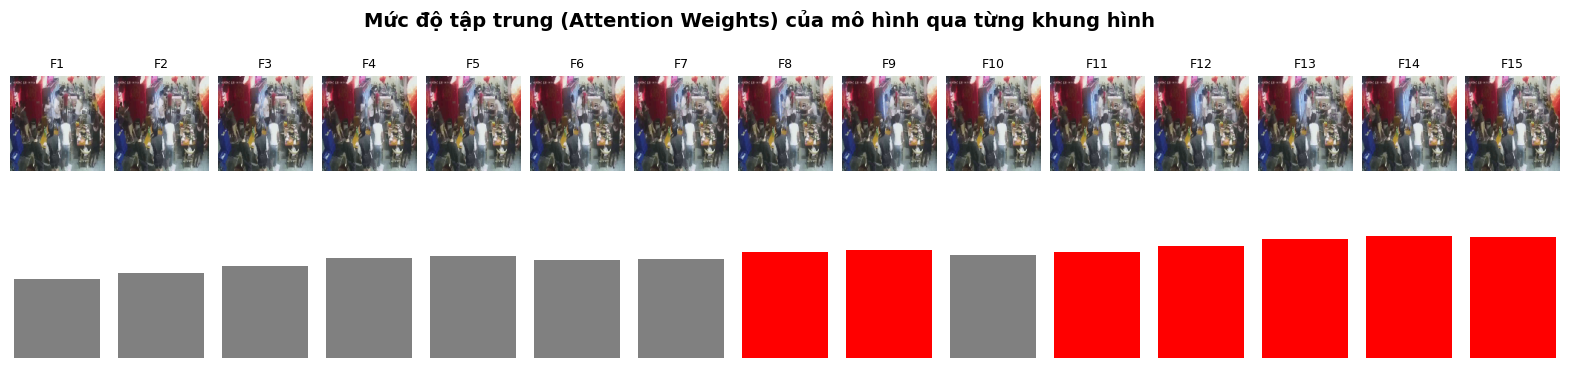


🔍 XAI Visualization cho video index #12 (2/4)
Thực tế: Normal | Dự đoán: Normal (Độ tin cậy: 68.93%)
✅ Đã lưu: /kaggle/working/output_results/charts/03_attention_xai_12.png


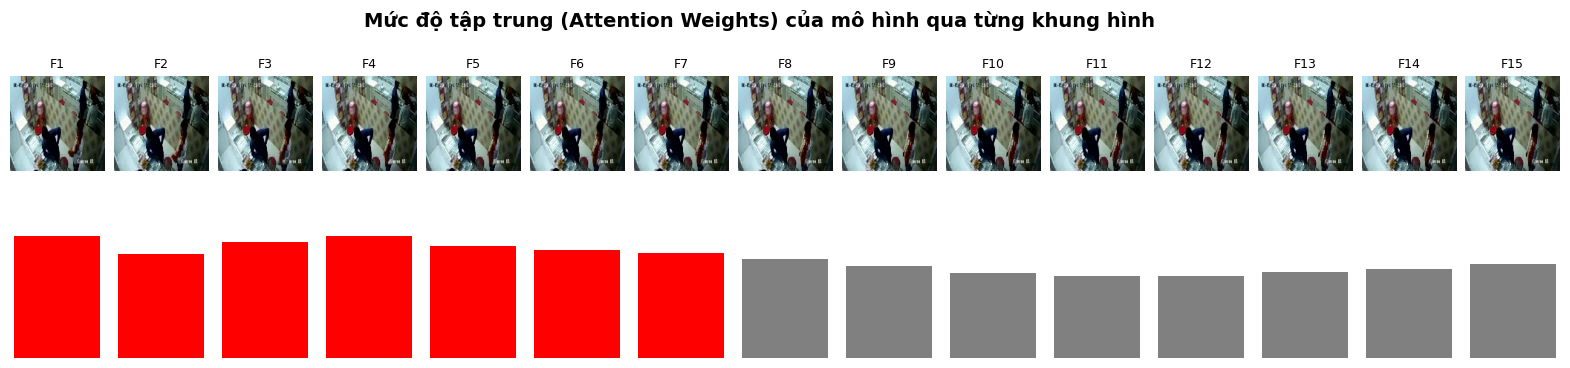


🔍 XAI Visualization cho video index #25 (3/4)
Thực tế: Normal | Dự đoán: Normal (Độ tin cậy: 86.38%)
✅ Đã lưu: /kaggle/working/output_results/charts/03_attention_xai_25.png


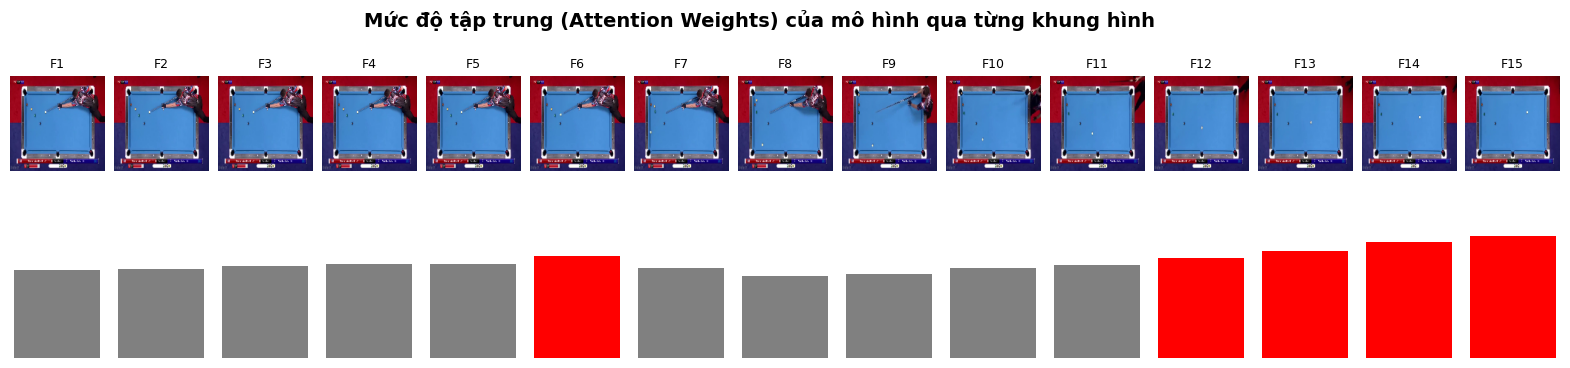


🔍 XAI Visualization cho video index #40 (4/4)
Thực tế: Normal | Dự đoán: Normal (Độ tin cậy: 95.27%)
✅ Đã lưu: /kaggle/working/output_results/charts/03_attention_xai_40.png


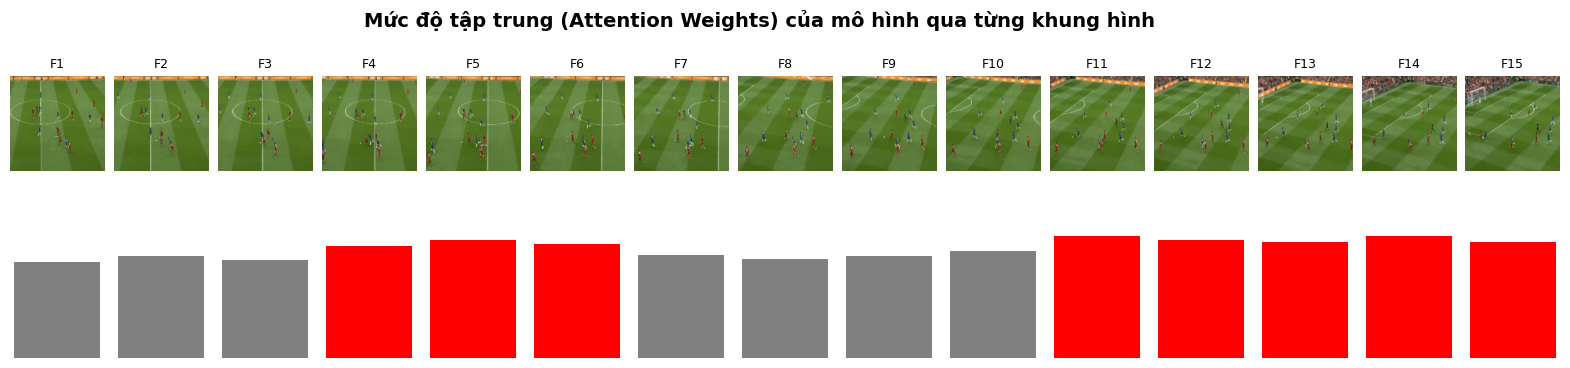

In [10]:
def save_attention_visualization(video_index=0, save_path=None):
    X_batch, y_batch = test_gen[video_index // BATCH_SIZE]
    idx_in_batch = video_index % BATCH_SIZE
    sample_video = X_batch[idx_in_batch]
    true_label = np.argmax(y_batch[idx_in_batch])

    pred_probs, att_weights = attention_model.predict(np.expand_dims(sample_video, axis=0), verbose=0)
    pred_label = np.argmax(pred_probs[0])
    att_weights = att_weights[0]

    print(f"Thực tế: {CLASSES[true_label]} | Dự đoán: {CLASSES[pred_label]} "
          f"(Độ tin cậy: {pred_probs[0][pred_label]*100:.2f}%)")

    fig, axes = plt.subplots(2, FRAME_COUNT, figsize=(20, 4))
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    for i in range(FRAME_COUNT):
        frame_disp = np.clip((sample_video[i] + 1.0) / 2.0, 0.0, 1.0)
        axes[0, i].imshow(frame_disp); axes[0, i].axis('off')
        axes[0, i].set_title(f"F{i+1}", fontsize=9)
        axes[1, i].bar([0], [att_weights[i]], color='red' if att_weights[i] > (1.0/FRAME_COUNT) else 'gray')
        axes[1, i].set_ylim(0, max(att_weights) * 1.2); axes[1, i].axis('off')

    fig.suptitle('Mức độ tập trung (Attention Weights) của mô hình qua từng khung hình', fontweight='bold', fontsize=14)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Đã lưu: {save_path}")
    plt.show()

# ==================== CẢI THIỆN: CHẠY NHIỀU VIDEO ====================
xai_indices = [0, 12, 25, 40]
for i, vid_idx in enumerate(xai_indices):
    save_path_i = f'{OUTPUT_DIR}/charts/03_attention_xai_{vid_idx}.png'
    print(f"\n🔍 XAI Visualization cho video index #{vid_idx} ({i+1}/{len(xai_indices)})")
    save_attention_visualization(video_index=vid_idx, save_path=save_path_i)

In [11]:
# =====================================================================
# 📦 ĐÓNG GÓI TẤT CẢ VÀO FILE ZIP ĐỂ TẢI VỀ
# =====================================================================
zip_path = f'/kaggle/working/CCTV_Violence_Results_{datetime.now().strftime("%Y%m%d_%H%M")}.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, OUTPUT_DIR)
            zf.write(full_path, arcname)

print(f"\n📦 Đã tạo file ZIP: {zip_path}")
print(f"   Kích thước: {os.path.getsize(zip_path)/1024/1024:.2f} MB")
print(f"\n📋 Nội dung bên trong:")
with zipfile.ZipFile(zip_path, 'r') as zf:
    for info in zf.infolist():
        print(f"   ├── {info.filename:50s}  ({info.file_size/1024:.1f} KB)")

print(f"\n✅ Hoàn tất! Tải về tại: Kaggle → Output → Files → {os.path.basename(zip_path)}")


📦 Đã tạo file ZIP: /kaggle/working/CCTV_Violence_Results_20260327_2352.zip
   Kích thước: 53.66 MB

📋 Nội dung bên trong:
   ├── charts/03_attention_xai_12.png                      (361.9 KB)
   ├── charts/02_evaluation_charts.png                     (133.0 KB)
   ├── charts/03_attention_xai_0.png                       (411.2 KB)
   ├── charts/01_learning_curves.png                       (100.4 KB)
   ├── charts/03_attention_xai_25.png                      (343.8 KB)
   ├── charts/03_attention_xai_40.png                      (408.1 KB)
   ├── models/CCTV_Violence_Finetuned.keras                (29503.7 KB)
   ├── models/CCTV_Violence_Final.keras                    (17555.7 KB)
   ├── models/CCTV_Violence_Attention.keras                (12097.6 KB)
   ├── reports/model_summary.txt                           (8.2 KB)
   ├── reports/config.json                                 (0.5 KB)
   ├── reports/classification_report.txt                   (0.4 KB)

✅ Hoàn tất! Tải về tại: Kaggle → Out